## Import Libraries 

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score , KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.models import Sequential 
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.activations import sigmoid , relu , leaky_relu , sigmoid
from tensorflow.keras.metrics import Accuracy , Precision , Recall
from tensorflow.keras.callbacks import EarlyStopping

## Load and Understand dataset

In [205]:
df = pd.read_csv('CustomerChurn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [206]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [207]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors="coerce")

In [208]:
df.shape

(7043, 21)

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [210]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [211]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## EDA and Preprocessing

check missing

In [212]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [213]:
missing_cols = ['TotalCharges']

check duplicates

In [214]:
df.duplicated().sum()

np.int64(0)

distributions

In [215]:
# Target distribuiton
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [216]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
catg_cols = df.select_dtypes(include=object).columns.to_list()

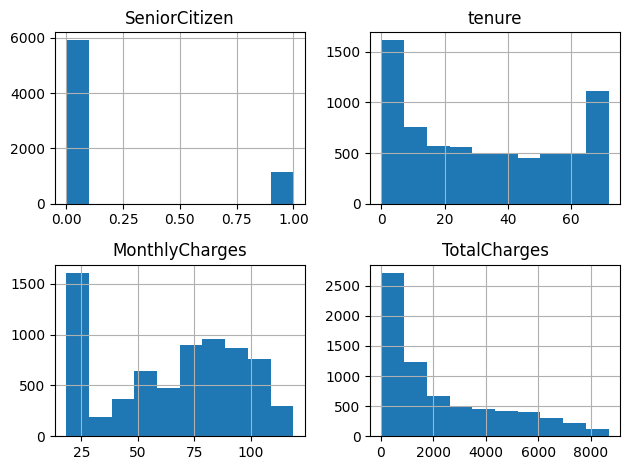

In [217]:
df[num_cols].hist()
plt.tight_layout()
plt.show()

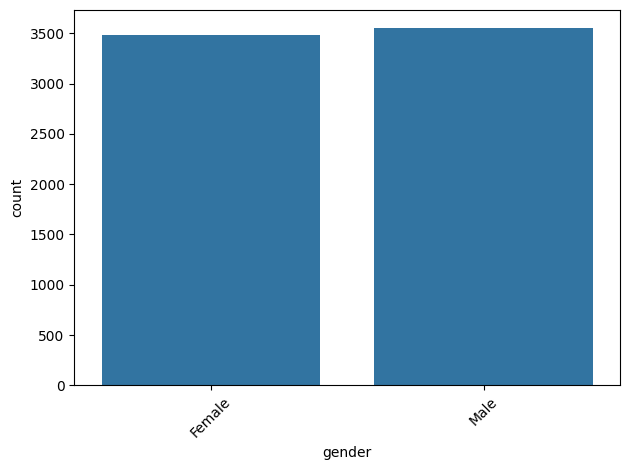

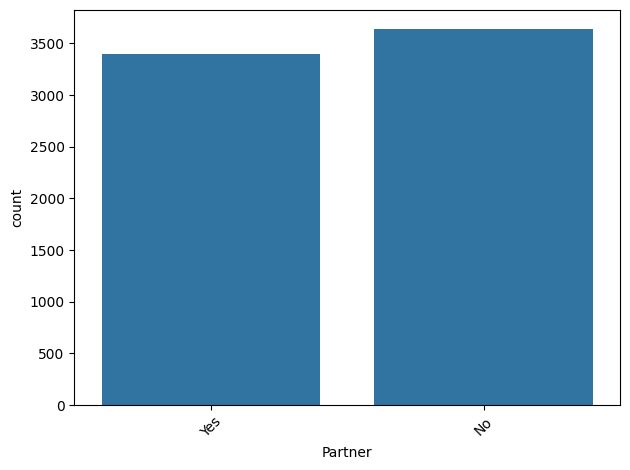

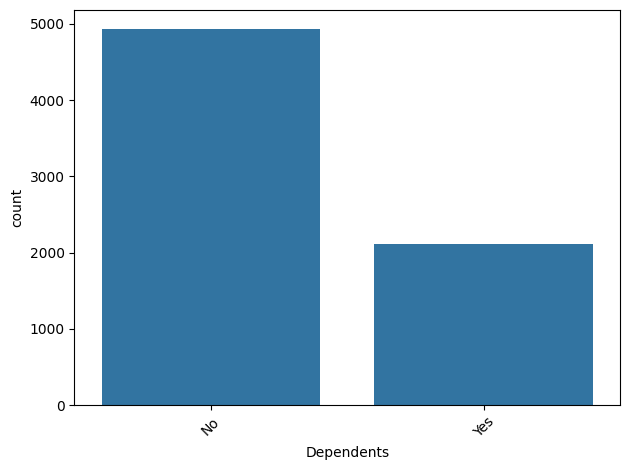

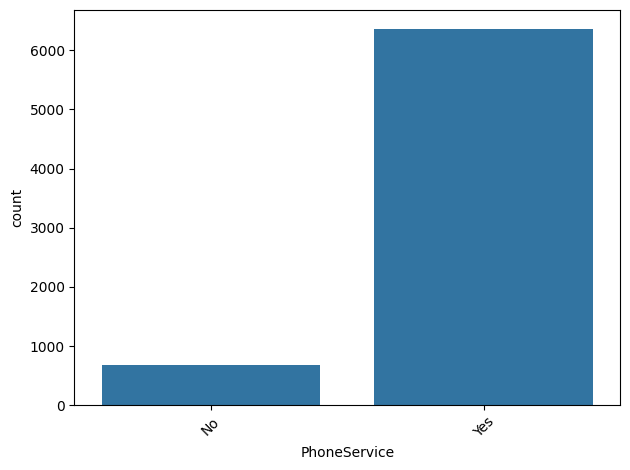

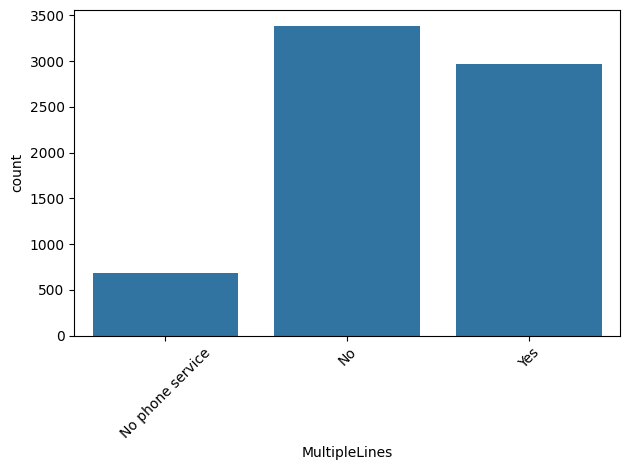

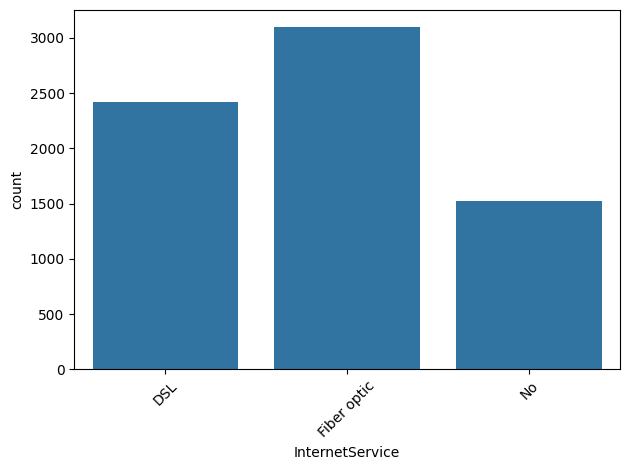

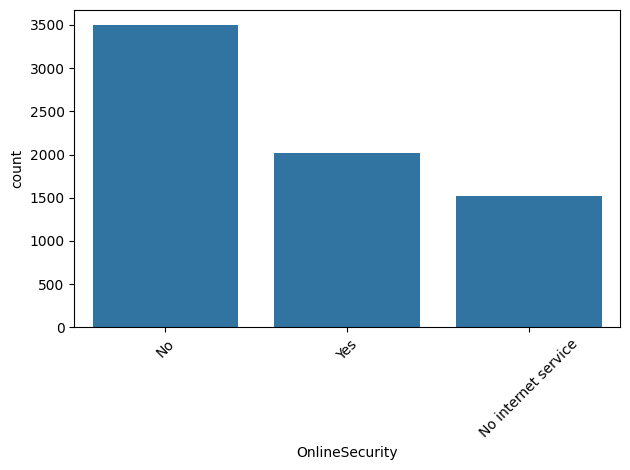

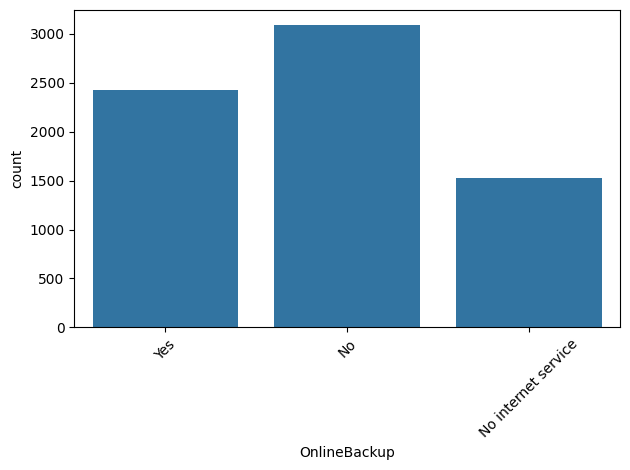

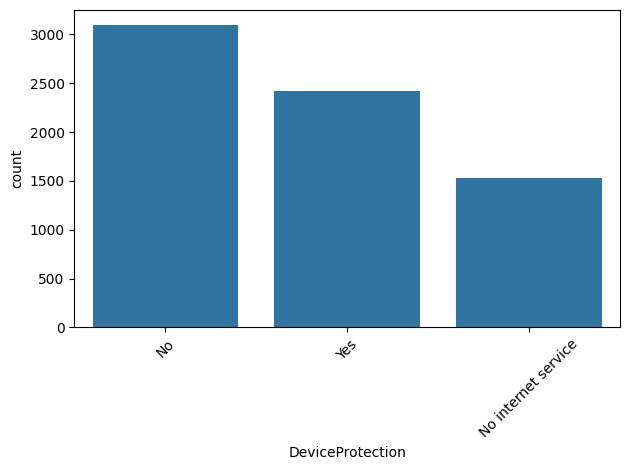

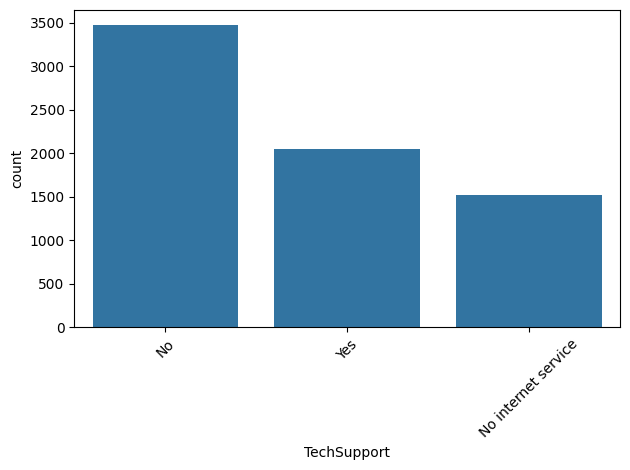

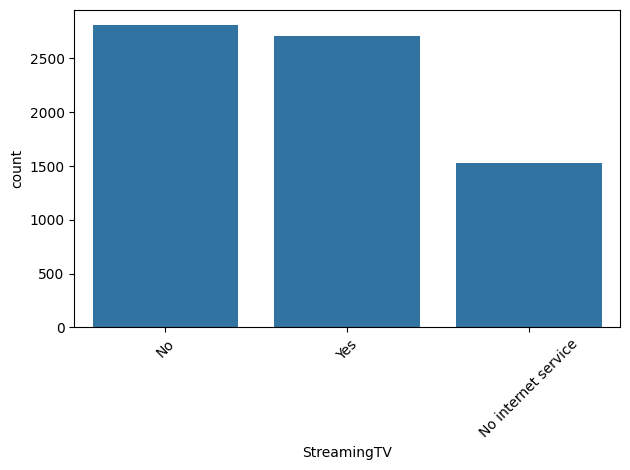

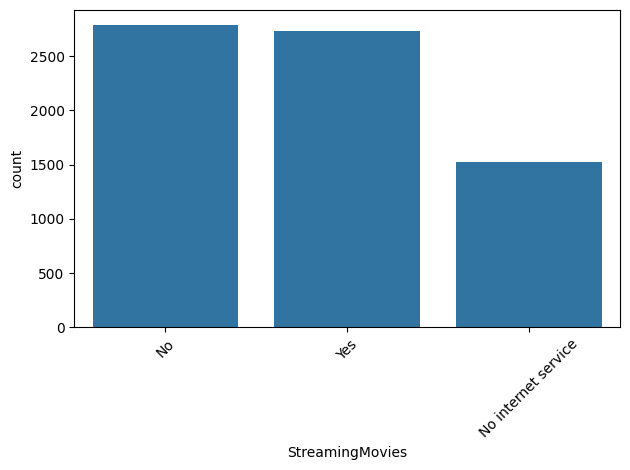

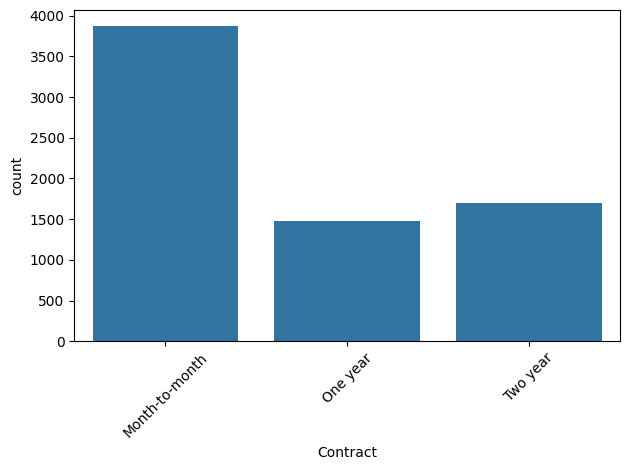

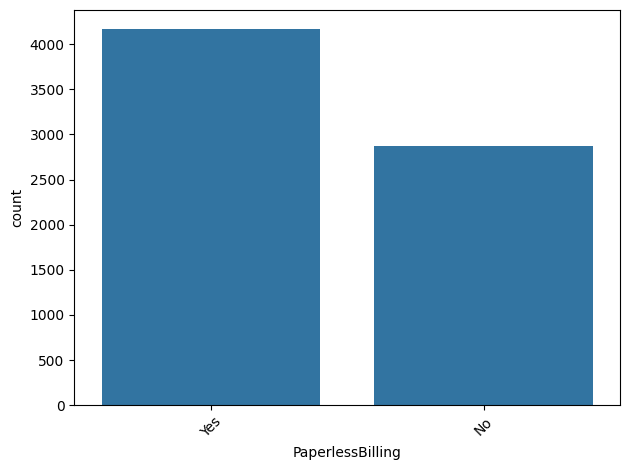

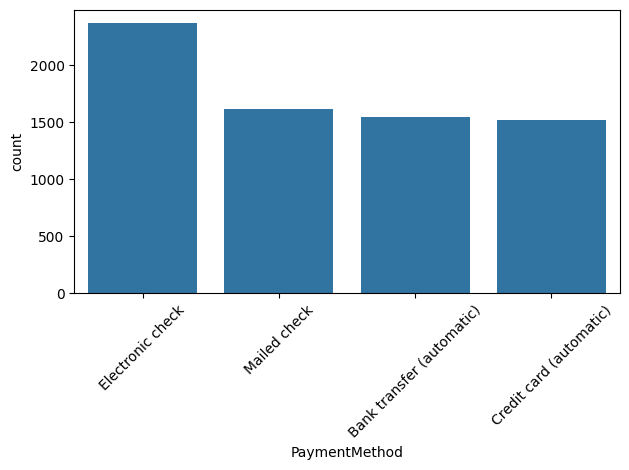

In [218]:
for col in catg_cols:
    if col not in ["Churn" , "customerID"]:
        sns.countplot(df , x = col)
        plt.xticks(rotation = 45)
        plt.tight_layout()
        plt.show()

In [219]:
encoded_cols = df[catg_cols].columns[df[catg_cols].nunique() >= 2].to_list()
del encoded_cols[-1]

encoded_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

Boxplot

In [220]:
df[num_cols].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [221]:
cols_to_scale = ['tenure' , "MonthlyCharges" ,'TotalCharges']

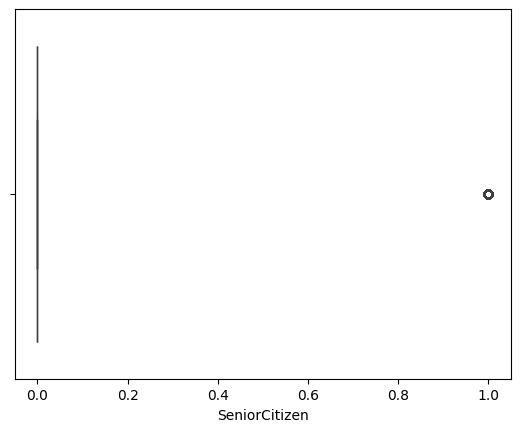

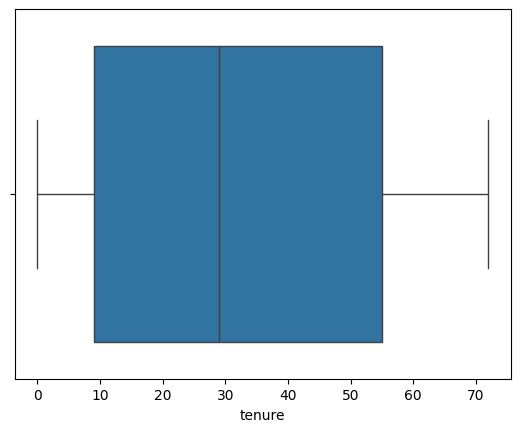

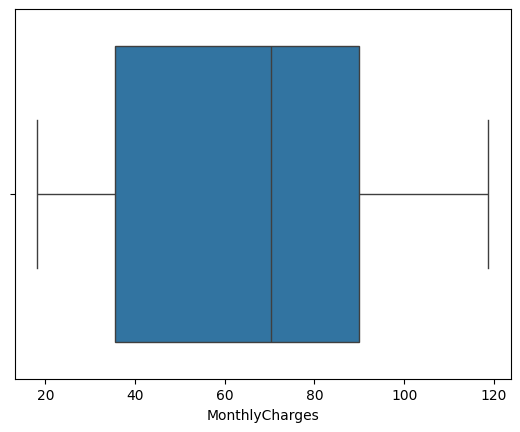

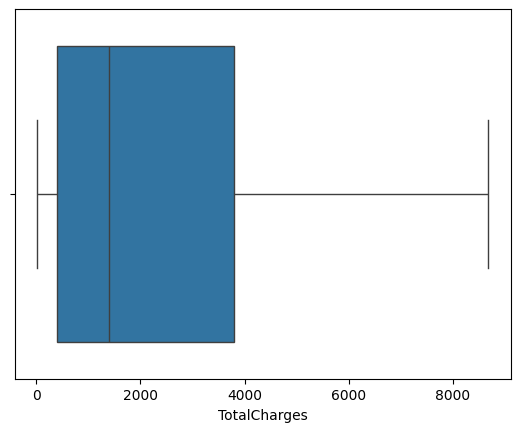

In [222]:
for col in num_cols:
    sns.boxplot(df ,  x  = col)
    plt.show()

Pipeline creation

In [223]:
preprocessor = ColumnTransformer([
    ('missing_col' , SimpleImputer(strategy="median") , missing_cols),
    ('encoded_cols' , OneHotEncoder(sparse_output=False , drop="first" , handle_unknown='ignore') , encoded_cols),
    ('scaled_cols' , MinMaxScaler() , cols_to_scale)
])

preprocessor

,transformers,"[('missing_col', ...), ('encoded_cols', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Model Build

Data Split

In [224]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

In [225]:
df['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [226]:
X = df.drop("Churn" , axis = 1)
y = df['Churn']

In [227]:
# 80 train , 20 temp
X_train , X_temp , y_train , y_temp = train_test_split(X , y , test_size=0.2 , random_state=42 , stratify=y)

# split 20 into 10 val and 10 test
X_val , X_test , y_val , y_test = train_test_split(X_temp , y_temp , random_state=42 , test_size=0.5 , stratify=y_temp)

In [228]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
X_val_preprocessed = preprocessor.transform(X_val)

c:\Users\Bassam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Bassam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [233]:
model = Sequential([
    # input layer
    Dense(units=32 , activation=leaky_relu , input_shape=(X_train_preprocessed.shape[1],)),
    Dropout(0.3),
    
    # hidden layers
    Dense(units=16 , activation=leaky_relu),
    Dropout(0.2),
    
    Dense(units=13 , activation=relu),
    Dropout(0.2),
    
    Dense(units=8 , activation= relu),
    Dropout(0.1),
    
    Dense(units=5,activation=relu),
    Dropout(0.3),
    
    # output layer
    Dense(units=1 , activation=sigmoid)
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 32)             │       181,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 13)             │           221 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,160 (711.56 KB)

 Trainable params: 182,160 (711.56 KB)

 Non-trainable params: 0 (0.00 B)

In [234]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics=[
            "accuracy",
            Precision(name="precision"),
            Recall(name="recall")
        ]
)

In [235]:
early_stop = EarlyStopping(
    monitor="val_loss",
    verbose=0,
    patience=15,
    restore_best_weights=True
)

In [236]:
history_clf = model.fit(
    X_train_preprocessed , y_train,
    epochs = 150,
    validation_data = (X_val_preprocessed , y_val),
    verbose = 1,
    callbacks = [early_stop],
    batch_size = 32
)

Epoch 1/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7245 - loss: 0.7551 - precision: 0.2432 - recall: 0.0181 - val_accuracy: 0.7344 - val_loss: 0.6241 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7346 - loss: 0.6055 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7344 - val_loss: 0.5896 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7346 - loss: 0.5909 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7344 - val_loss: 0.5813 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7346 - loss: 0.5842 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7344 - val_loss: 0.5798 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7346 - loss: 0.5856 - precision: 

In [237]:
print(f"Acc = {history_clf.history['accuracy'][-1] * 100 :.2f}")

Acc = 73.46


In [238]:
print(f"Stopped after {len(history_clf.history['loss'])} epochs.")

Stopped after 57 epochs.
